In [ ]:
# Import Libraries
import requests
import pandas as pd
import matplotlib.pyplot as plt 
from sqlalchemy import create_engine

In [2]:
%pip install sqlalchemy

   ---------------------------------------- 0.0/2.1 MB ? eta -:--:--
   -------------- ------------------------- 0.8/2.1 MB 7.4 MB/s eta 0:00:01
   ---------------------------------------- 2.1/2.1 MB 7.5 MB/s  0:00:00

   ---------------------------------------- 0/2 [greenlet]
   ---------------------------------------- 0/2 [greenlet]
   -------------------- ------------------- 1/2 [sqlalchemy]
   -------------------- ------------------- 1/2 [sqlalchemy]
   -------------------- ------------------- 1/2 [sqlalchemy]
   -------------------- ------------------- 1/2 [sqlalchemy]
   -------------------- ------------------- 1/2 [sqlalchemy]
   -------------------- ------------------- 1/2 [sqlalchemy]
   -------------------- ------------------- 1/2 [sqlalchemy]
   -------------------- ------------------- 1/2 [sqlalchemy]
   -------------------- ------------------- 1/2 [sqlalchemy]
   -------------------- ------------------- 1/2 [sqlalchemy]
   -------------------- ------------------- 1/2 [sqla


[notice] A new release of pip is available: 25.2 -> 26.1.2
[notice] To update, run: python.exe -m pip install --upgrade pip


In [3]:
# Fetch Data from API
def get_news():
    ids_url =  "https://hacker-news.firebaseio.com/v0/topstories.json"
    ids =requests.get(ids_url).json()

    articles=[]

    for i in ids[:20]:
        item_url = f"https://hacker-news.firebaseio.com/v0/item/{i}.json"
        data = requests.get(item_url).json()

        articles.append(data)

    return articles


In [4]:
import requests

print(requests.get("https://hacker-news.firebaseio.com/v0/topstories.json").status_code)

200


In [5]:
news = get_news()
print(len(news))
print(news[:2])

20
[{'by': 'cloud8421', 'descendants': 240, 'id': 48388324, 'kids': [48392111, 48390262, 48391731, 48388593, 48389358, 48390549, 48389927, 48393583, 48390275, 48389948, 48393161, 48390917, 48393167, 48388548, 48389340, 48388817, 48389191, 48390797, 48392871, 48390194, 48392924, 48393060, 48393488, 48389398, 48389000], 'score': 651, 'time': 1780513346, 'title': 'Elixir v1.20: Now a gradually typed language', 'type': 'story', 'url': 'https://elixir-lang.org/blog/2026/06/03/elixir-v1-20-0-released/'}, {'by': 'MaxLeiter', 'descendants': 67, 'id': 48391611, 'kids': [48393124, 48392754, 48393713, 48393523, 48393468, 48393947, 48394138, 48393588, 48394157, 48392462, 48393090, 48392685], 'score': 202, 'time': 1780529838, 'title': '"They\'re made out of weights"', 'type': 'story', 'url': 'https://maxleiter.com/blog/weights'}]


In [7]:
import pandas as pd

df = pd.DataFrame(news)
df.head()

,by,descendants,id,kids,score,time,title,type,url,text
0,cloud8421,240,48388324,"[48392111, 48390262, 48391731, 48388593, 48389...",651,1780513346,Elixir v1.20: Now a gradually typed language,story,https://elixir-lang.org/blog/2026/06/03/elixir...,NaN
1,MaxLeiter,67,48391611,"[48393124, 48392754, 48393713, 48393523, 48393...",202,1780529838,"""They're made out of weights""",story,https://maxleiter.com/blog/weights,NaN
2,littlexsparkee,62,48392004,"[48393790, 48393800, 48393796, 48393054, 48394...",116,1780532282,"Failing grades soar with AI usage, dwindling m...",story,https://www.dailycal.org/news/campus/academics...,NaN
3,jc4p,45,48392343,"[48392551, 48393196, 48392676, 48393303, 48394...",117,1780534592,"I built a vulnerable app and spent $1,500 seei...",story,https://kasra.blog/blog/i-spent-1500-seeing-if...,NaN
4,rvz,307,48385906,"[48387695, 48386156, 48388066, 48386275, 48387...",768,1780502682,"Gemma 4 12B: A unified, encoder-free multimoda...",story,https://blog.google/innovation-and-ai/technolo...,NaN


In [8]:
df = df[["title", "by", "score", "time", "url"]]

In [9]:
df.rename(columns={
    "by": "author",
    "time": "created_time"
}, inplace=True)

In [10]:
import datetime

df["created_time"] = pd.to_datetime(df["created_time"], unit="s")

In [11]:
print("Total articles:", len(df))
print("\nTop Authors:")
print(df["author"].value_counts().head(10))

print("\nTop Scores:")
print(df.sort_values("score", ascending=False).head(5))

Total articles: 20

Top Authors:
author
cloud8421         1
MaxLeiter         1
littlexsparkee    1
jc4p              1
rvz               1
jbredeche         1
lordleft          1
Tomte             1
pdyc              1
pentagrama        1
Name: count, dtype: int64

Top Scores:
                                               title      author  score  \
4  Gemma 4 12B: A unified, encoder-free multimoda...         rvz    768   
0       Elixir v1.20: Now a gradually typed language   cloud8421    651   
7  I was recently diagnosed with anti-NMDA recept...       Tomte    548   
9                                 DaVinci Resolve 21  pentagrama    430   
8  Uber's $1,500/month AI limit is a useful signa...        pdyc    423   

         created_time                                                url  
4 2026-06-03 16:04:42  https://blog.google/innovation-and-ai/technolo...  
0 2026-06-03 19:02:26  https://elixir-lang.org/blog/2026/06/03/elixir...  
7 2026-06-03 14:10:06               https://b

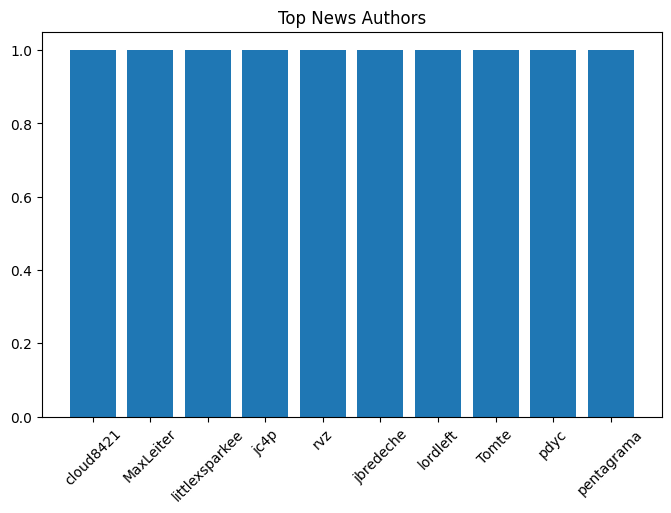

In [12]:
# Visualization
import matplotlib.pyplot as plt

author_counts = df["author"].value_counts().head(10)

plt.figure(figsize=(8,5))
plt.bar(author_counts.index, author_counts.values)

plt.title("Top News Authors")
plt.xticks(rotation=45)
plt.show()

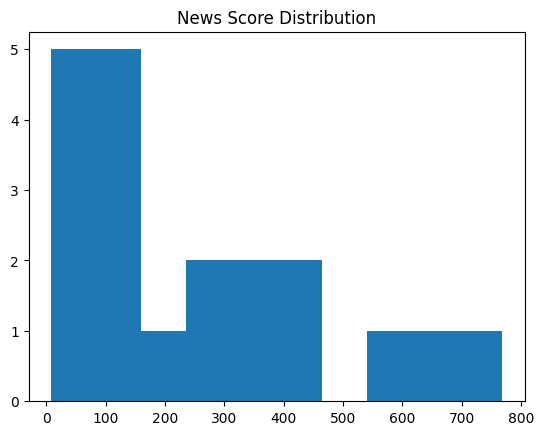

In [13]:
# Score distribution
plt.hist(df["score"], bins=10)
plt.title("News Score Distribution")
plt.show()

In [14]:
# Save to database
from sqlalchemy import create_engine

engine = create_engine("sqlite:///news.db")

df.to_sql("news", engine, if_exists="replace", index=False)

20